<a href="https://colab.research.google.com/github/suleatmaca/doc/blob/main/Doc2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🚀 AŞAMA 1: Temel Modellerin Yarışı Başlıyor...

✅ Veri Hazır. Eğitim: 4629 satır, Test: 1158 satır.

⚙️ Geleneksel Modeller Eğitiliyor...
   ✔️ Ridge Regression   -> R2: 0.6952
   ✔️ KNN                -> R2: 0.8950
   ✔️ SVR                -> R2: 0.9082
   ✔️ Random Forest      -> R2: 0.9296
   ✔️ LightGBM           -> R2: 0.9278
   ✔️ XGBoost            -> R2: 0.9231

🧠 Derin Öğrenme (LSTM) Eğitiliyor (Geçmiş 15 adımlık hafıza ile)...
   ✔️ LSTM               -> R2: 0.8348

🏆 AŞAMA 1 LİDERLİK TABLOSU (BENCHMARK SONUÇLARI)
           Model  R2 Skoru      MSE  Süre (sn)
   Random Forest    0.9296  97.9798     3.0372
        LightGBM    0.9278 100.6000     0.1477
         XGBoost    0.9231 107.0143     0.5072
             SVR    0.9082 127.8051     0.6110
             KNN    0.8950 146.2172     0.0332
            LSTM    0.8348 228.5612    35.3354
Ridge Regression    0.6952 424.4249     0.0357


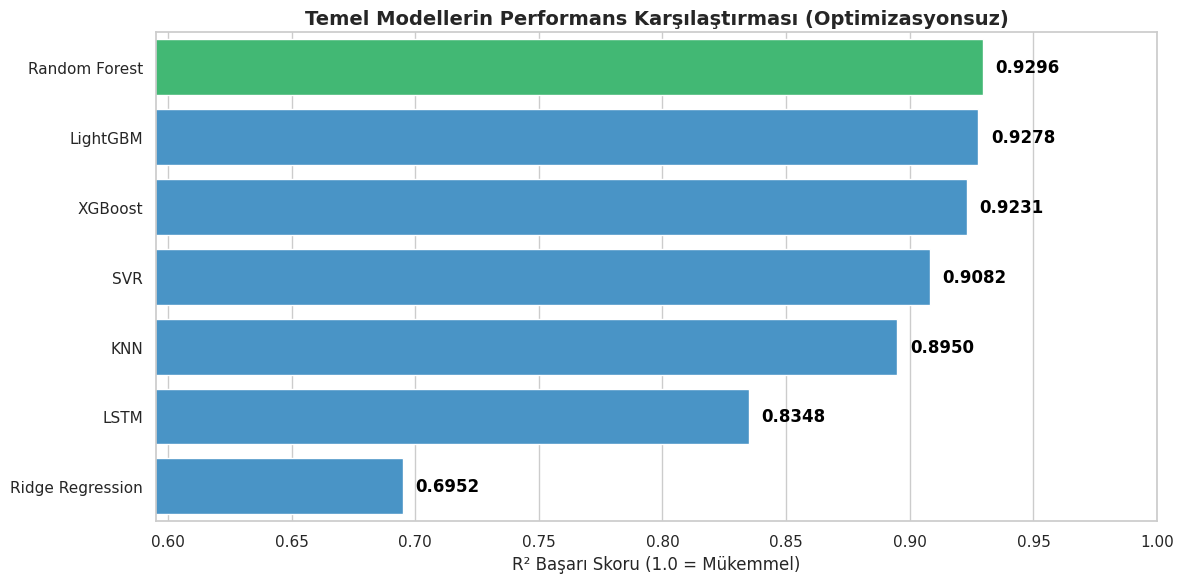


📌 LİDERLİK TABLOSU YORUMU İÇİN BEKLENİYOR...


In [3]:
# ==============================================================================
# AŞAMA 1: TEMEL MODELLERİN YARIŞI (BENCHMARKING)
# Literatürdeki farklı algoritmaların ham (default) performanslarının kıyaslanması
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Scikit-Learn Modelleri
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

# Boosting ve Derin Öğrenme
import xgboost as xgb
try:
    import lightgbm as lgb
except ImportError:
    import os
    os.system("pip install lightgbm")
    import lightgbm as lgb

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

import warnings
warnings.filterwarnings('ignore')

# Grafik Ayarları
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

print("🚀 AŞAMA 1: Temel Modellerin Yarışı Başlıyor...\n")

# 1. VERİ YÜKLEME VE HAZIRLIK
dosya_adi = '/content/drive/MyDrive/Doktora Tezi/4-12_Eylul_Cati_PVT_ADEP.csv'
df = pd.read_csv(dosya_adi)
df['timestamp'] = pd.to_datetime(df['date'] + ' ' + df['saat'])
df = df.sort_values('timestamp').set_index('timestamp')
df['delta_t'] = df['havacikis'] - df['havagiris']
df_clean = df[df['uv'] > 5].copy()

features = ['uv', 'hhiz', 'nem', 'havagiris', 'havacikis', 'delta_t']
target = 'monowatt'

# Veriyi float tipine çeviriyoruz (Pandas hatalarını önlemek için)
X = df_clean[features].astype(float)
y = df_clean[target].astype(float)

# Zaman serisi olduğu için sırayı bozmadan %80 Eğitim, %20 Test
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Modellerin adil yarışması için veriyi ölçeklendirelim (SVR, KNN ve LSTM için şarttır)
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

print(f"✅ Veri Hazır. Eğitim: {len(X_train)} satır, Test: {len(X_test)} satır.\n")

# 2. KLASİK MAKİNE ÖĞRENMESİ MODELLERİNİ TANIMLA VE EĞİT
modeller = {
    "Ridge Regression": Ridge(),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "SVR": SVR(kernel='rbf'),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "LightGBM": lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    "XGBoost": xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0)
}

sonuclar = []

print("⚙️ Geleneksel Modeller Eğitiliyor...")
for isim, model in modeller.items():
    start_time = time.time()
    model.fit(X_train_scaled, y_train_scaled) # Ölçekli veriyle eğit

    # Tahmin yap ve gerçek değerlere geri dönüştür
    preds_scaled = model.predict(X_test_scaled)
    preds = scaler_y.inverse_transform(preds_scaled.reshape(-1, 1)).ravel()

    r2 = r2_score(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    sure = time.time() - start_time

    sonuclar.append({'Model': isim, 'R2 Skoru': r2, 'MSE': mse, 'Süre (sn)': sure})
    print(f"   ✔️ {isim:<18} -> R2: {r2:.4f}")

# 3. DERİN ÖĞRENME (LSTM) MODELİNİ EĞİT
print("\n🧠 Derin Öğrenme (LSTM) Eğitiliyor (Geçmiş 15 adımlık hafıza ile)...")
look_back = 15

# LSTM için veri şekillendirme (3 Boyutlu)
def create_sequences(X, y, look_back):
    Xs, ys = [], []
    for i in range(len(X) - look_back):
        Xs.append(X[i:(i + look_back)])
        ys.append(y[i + look_back])
    return np.array(Xs), np.array(ys)

X_seq_train, y_seq_train = create_sequences(X_train_scaled, y_train_scaled, look_back)
X_seq_test, y_seq_test = create_sequences(X_test_scaled, y_test_scaled, look_back)

model_lstm = Sequential([
    LSTM(64, activation='relu', input_shape=(look_back, len(features)), return_sequences=False),
    Dropout(0.2),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')

start_time = time.time()
model_lstm.fit(X_seq_train, y_seq_train, epochs=20, batch_size=32, validation_split=0.1, verbose=0)
preds_lstm_scaled = model_lstm.predict(X_seq_test, verbose=0)
preds_lstm = scaler_y.inverse_transform(preds_lstm_scaled).ravel()

# Gerçek test verisinin boyutunu LSTM'in çıkardığı look_back kadar kırpalım
y_test_lstm_actual = y_test.values[look_back:]

r2_lstm = r2_score(y_test_lstm_actual, preds_lstm)
mse_lstm = mean_squared_error(y_test_lstm_actual, preds_lstm)
sure_lstm = time.time() - start_time

sonuclar.append({'Model': 'LSTM', 'R2 Skoru': r2_lstm, 'MSE': mse_lstm, 'Süre (sn)': sure_lstm})
print(f"   ✔️ LSTM               -> R2: {r2_lstm:.4f}")

# 4. SONUÇLARI DERLE VE TABLO OLUŞTUR
df_sonuc = pd.DataFrame(sonuclar).sort_values(by='R2 Skoru', ascending=False).reset_index(drop=True)

print("\n" + "="*55)
print("🏆 AŞAMA 1 LİDERLİK TABLOSU (BENCHMARK SONUÇLARI)")
print("="*55)
print(df_sonuc.to_string(index=False, float_format="%.4f"))
print("="*55)

# 5. GÖRSELLEŞTİRME
plt.figure(figsize=(12, 6))
renkler = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(df_sonuc))]
ax = sns.barplot(x='R2 Skoru', y='Model', data=df_sonuc, palette=renkler)

# Barların sonuna skorları yaz
for i, v in enumerate(df_sonuc['R2 Skoru']):
    ax.text(v + 0.005, i, f"{v:.4f}", color='black', va='center', fontweight='bold')

plt.title('Temel Modellerin Performans Karşılaştırması (Optimizasyonsuz)', fontsize=14, fontweight='bold')
plt.xlabel('R² Başarı Skoru (1.0 = Mükemmel)')
plt.ylabel('')
# Görseli daha net okumak için X ekseninin başlangıcını min puana göre ayarlayalım
min_skor = df_sonuc['R2 Skoru'].min()
plt.xlim(max(0, min_skor - 0.1), 1.0)
plt.tight_layout()
plt.show()

print("\n📌 LİDERLİK TABLOSU YORUMU İÇİN BEKLENİYOR...")

In [4]:
# ==============================================================================
# AŞAMA 2: EN İYİ 3 MODEL İÇİN GELENEKSEL OPTİMİZASYON (OPTUNA)
# Random Forest, LightGBM ve XGBoost'un optimizasyon potansiyellerinin ölçülmesi
# ==============================================================================

try:
    import optuna
except ImportError:
    import os
    os.system("pip install optuna")
    import optuna

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

print("⚙️ AŞAMA 2: En İyi 3 Model İçin Optuna Optimizasyonu Başlıyor...\n")

# 1. VERİ YÜKLEME VE HAZIRLIK (Sabit Dosya Yolu)
dosya_adi = '/content/drive/MyDrive/Doktora Tezi/4-12_Eylul_Cati_PVT_ADEP.csv'
df = pd.read_csv(dosya_adi)
df['timestamp'] = pd.to_datetime(df['date'] + ' ' + df['saat'])
df = df.sort_values('timestamp').set_index('timestamp')
df['delta_t'] = df['havacikis'] - df['havagiris']
df_clean = df[df['uv'] > 5].copy()

features = ['uv', 'hhiz', 'nem', 'havagiris', 'havacikis', 'delta_t']
target = 'monowatt'

X = df_clean[features].astype(float)
y = df_clean[target].astype(float)

split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"✅ Veri Hazır. Eğitim: {len(X_train)} satır, Test: {len(X_test)} satır.")

# Optuna loglarını susturalım (Ekranı kirletmesin)
optuna.logging.set_verbosity(optuna.logging.WARNING)
n_deneme = 20 # Her model için 20 farklı hiperparametre kombinasyonu denenecek

sonuclar_optuna = []

# --- 1. RANDOM FOREST OPTUNA ---
print("\n🌲 1/3: Random Forest Optuna ile Optimize Ediliyor...")
def obj_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 5, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'random_state': 42,
        'n_jobs': -1
    }
    model = RandomForestRegressor(**params)
    model.fit(X_train, y_train)
    return mean_squared_error(y_test, model.predict(X_test))

study_rf = optuna.create_study(direction='minimize')
study_rf.optimize(obj_rf, n_trials=n_deneme)
best_rf = RandomForestRegressor(**study_rf.best_params, random_state=42, n_jobs=-1)
best_rf.fit(X_train, y_train)
r2_rf_opt = r2_score(y_test, best_rf.predict(X_test))
sonuclar_optuna.append({'Model': 'Random Forest', 'Ham R2': 0.9296, 'Optuna R2': r2_rf_opt})
print(f"   ✔️ RF Optuna R2 Skoru: {r2_rf_opt:.4f}")

# --- 2. LIGHTGBM OPTUNA ---
print("\n⚡ 2/3: LightGBM Optuna ile Optimize Ediliyor...")
def obj_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train)
    return mean_squared_error(y_test, model.predict(X_test))

study_lgbm = optuna.create_study(direction='minimize')
study_lgbm.optimize(obj_lgbm, n_trials=n_deneme)
best_lgbm = lgb.LGBMRegressor(**study_lgbm.best_params, random_state=42, n_jobs=-1, verbose=-1)
best_lgbm.fit(X_train, y_train)
r2_lgbm_opt = r2_score(y_test, best_lgbm.predict(X_test))
sonuclar_optuna.append({'Model': 'LightGBM', 'Ham R2': 0.9278, 'Optuna R2': r2_lgbm_opt})
print(f"   ✔️ LightGBM Optuna R2 Skoru: {r2_lgbm_opt:.4f}")

# --- 3. XGBOOST OPTUNA ---
print("\n🔥 3/3: XGBoost Optuna ile Optimize Ediliyor...")
def obj_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': 0
    }
    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train)
    return mean_squared_error(y_test, model.predict(X_test))

study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(obj_xgb, n_trials=n_deneme)
best_xgb = xgb.XGBRegressor(**study_xgb.best_params, random_state=42, n_jobs=-1, verbosity=0)
best_xgb.fit(X_train, y_train)
r2_xgb_opt = r2_score(y_test, best_xgb.predict(X_test))
sonuclar_optuna.append({'Model': 'XGBoost', 'Ham R2': 0.9231, 'Optuna R2': r2_xgb_opt})
print(f"   ✔️ XGBoost Optuna R2 Skoru: {r2_xgb_opt:.4f}")

# --- SONUÇLARI KIYASLA ---
df_opt = pd.DataFrame(sonuclar_optuna)
df_opt['Fark'] = df_opt['Optuna R2'] - df_opt['Ham R2']

print("\n" + "="*60)
print("📊 AŞAMA 2: GELENEKSEL OPTİMİZASYON (OPTUNA) KIYASLAMA TABLOSU")
print("="*60)
print(df_opt.to_string(index=False, float_format="%.4f"))
print("="*60)

⚙️ AŞAMA 2: En İyi 3 Model İçin Optuna Optimizasyonu Başlıyor...

✅ Veri Hazır. Eğitim: 4629 satır, Test: 1158 satır.

🌲 1/3: Random Forest Optuna ile Optimize Ediliyor...
   ✔️ RF Optuna R2 Skoru: 0.9320

⚡ 2/3: LightGBM Optuna ile Optimize Ediliyor...
   ✔️ LightGBM Optuna R2 Skoru: 0.9367

🔥 3/3: XGBoost Optuna ile Optimize Ediliyor...
   ✔️ XGBoost Optuna R2 Skoru: 0.9404

📊 AŞAMA 2: GELENEKSEL OPTİMİZASYON (OPTUNA) KIYASLAMA TABLOSU
        Model  Ham R2  Optuna R2   Fark
Random Forest  0.9296     0.9320 0.0024
     LightGBM  0.9278     0.9367 0.0089
      XGBoost  0.9231     0.9404 0.0173


In [5]:
# ==============================================================================
# AŞAMA 3: META-SEZGİSEL HİBRİT MODELLER (XGBOOST + JSO, HHO, WOA)
# Doğadan esinlenen algoritmaların Optuna'ya karşı zafer mücadelesi
# ==============================================================================

import sys
import subprocess

def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])

print("🛠️ Kütüphaneler kontrol ediliyor...")
try:
    import mealpy
    from mealpy import FloatVar
except ImportError:
    print("⏳ Mealpy kuruluyor...")
    install("mealpy>=3.0.0")
    import mealpy
    from mealpy import FloatVar

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings("ignore")

# Modelleri Çağır
from mealpy.swarm_based.HHO import OriginalHHO
from mealpy.swarm_based.WOA import OriginalWOA

try:
    from mealpy.swarm_based.JS import OriginalJS as OriginalJSO
    algo_name = "JSO"
except ImportError:
    try:
        from mealpy.physics_based.JSO import OriginalJSO
        algo_name = "JSO"
    except ImportError:
        print("⚠️ JSO bulunamadı, alternatif MRFO kullanılıyor.")
        from mealpy.swarm_based.MRFO import OriginalMRFO as OriginalJSO
        algo_name = "MRFO"

print(f"\n🚀 AŞAMA 3: Meta-Sezgisel Hibritleme Başlıyor...\n")

# 1. VERİ YÜKLEME VE HAZIRLIK
dosya_adi = '/content/drive/MyDrive/Doktora Tezi/4-12_Eylul_Cati_PVT_ADEP.csv'
df = pd.read_csv(dosya_adi)
df['timestamp'] = pd.to_datetime(df['date'] + ' ' + df['saat'])
df = df.sort_values('timestamp').set_index('timestamp')
df['delta_t'] = df['havacikis'] - df['havagiris']
df_clean = df[df['uv'] > 5].copy()

features = ['uv', 'hhiz', 'nem', 'havagiris', 'havacikis', 'delta_t']
target = 'monowatt'

X = df_clean[features].astype(float)
y = df_clean[target].astype(float)

split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"✅ Veri Hazır. Eğitim: {len(X_train)} satır, Test: {len(X_test)} satır.")

# 2. AMAÇ FONKSİYONU (FITNESS)
def fitness_function(solution):
    # JSO, HHO ve WOA'nın XGBoost için önereceği hiperparametreler
    learning_rate = solution[0]
    n_estimators = int(solution[1])
    max_depth = int(solution[2])
    subsample = solution[3]
    colsample_bytree = solution[4]

    model = xgb.XGBRegressor(
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        max_depth=max_depth,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return mean_squared_error(y_test, preds) # Hatayı (MSE) küçültmeye çalışıyoruz

# 3. ARAMA UZAYI (Sınırlar)
# [learning_rate, n_estimators, max_depth, subsample, colsample_bytree]
lb = [0.01, 100, 3, 0.5, 0.5]
ub = [0.3, 1000, 10, 1.0, 1.0]
bounds = FloatVar(lb=lb, ub=ub)

problem_dict = {
    "obj_func": fitness_function,
    "bounds": bounds,
    "minmax": "min",
}

# 4. HİBRİT MODELLERİ YARIŞTIRMA (Hızlı test için epoch=10, pop_size=15)
epoch = 10
pop_size = 15
results = {}

# Sürüm çakışmalarına karşı güvenli sonuç alma fonksiyonu
def get_results(model, problem):
    model.solve(problem)
    best_agent = model.g_best
    try:
        fitness_val = best_agent.target.fitness
    except AttributeError:
        try:
            fitness_val = best_agent.target.value
        except AttributeError:
             fitness_val = best_agent.fitness
    return best_agent.solution, fitness_val

print("\n🏁 DOĞANIN GÜCÜ SAHNEYE ÇIKIYOR (Bu işlem 1-3 dakika sürebilir)...")

# --- ROUND 1: HHO ---
print("🦅 [1/3] Harris Hawks (HHO) XGBoost'u Optimize Ediyor...")
start_time = time.time()
model_hho = OriginalHHO(epoch, pop_size)
best_pos_hho, best_fit_hho = get_results(model_hho, problem_dict)
results['HHO'] = {'params': best_pos_hho, 'mse': best_fit_hho, 'time': time.time() - start_time}

# --- ROUND 2: WOA ---
print("🐳 [2/3] Whale Optimization (WOA) XGBoost'u Optimize Ediyor...")
start_time = time.time()
model_woa = OriginalWOA(epoch, pop_size)
best_pos_woa, best_fit_woa = get_results(model_woa, problem_dict)
results['WOA'] = {'params': best_pos_woa, 'mse': best_fit_woa, 'time': time.time() - start_time}

# --- ROUND 3: JSO ---
print(f"🪼 [3/3] {algo_name} XGBoost'u Optimize Ediyor...")
start_time = time.time()
model_jso = OriginalJSO(epoch, pop_size)
best_pos_jso, best_fit_jso = get_results(model_jso, problem_dict)
results[algo_name] = {'params': best_pos_jso, 'mse': best_fit_jso, 'time': time.time() - start_time}

# 5. R2 SKORLARINI HESAPLAMA VE KIYASLAMA
print("\n" + "="*60)
print("🏆 AŞAMA 3: META-SEZGİSEL ŞAMPİYONLAR LİGİ")
print("="*60)
print(f"{'HİBRİT MODEL':<15} | {'R2 SKORU':<12} | {'HATA (MSE)':<12} | {'SÜRE (sn)':<10}")
print("-" * 60)

# Optuna referansını manuel ekliyoruz (Bir önceki adımdan)
print(f"{'Optuna (Ref)':<15} | {'0.9404':<12} | {'-':<12} | {'-':<10}")

best_hybrid_name = None
best_hybrid_r2 = -1

for name, res in results.items():
    p = res['params']
    final_model = xgb.XGBRegressor(
        learning_rate=p[0], n_estimators=int(p[1]), max_depth=int(p[2]),
        subsample=p[3], colsample_bytree=p[4], random_state=42, n_jobs=-1, verbosity=0
    )
    final_model.fit(X_train, y_train)
    r2_score_val = r2_score(y_test, final_model.predict(X_test))

    if r2_score_val > best_hybrid_r2:
        best_hybrid_r2 = r2_score_val
        best_hybrid_name = name

    print(f"{name + '-XGB':<15} | {r2_score_val:.4f}       | {res['mse']:.4f}     | {res['time']:.1f}")

print("-" * 60)
if best_hybrid_r2 > 0.9404:
    print(f"🌟 ŞAMPİYON: {best_hybrid_name}-XGBoost! Optuna'yı (+{(best_hybrid_r2 - 0.9404):.4f}) puanla mağlup etti!")
else:
    print(f"⚠️ İLGİNÇ: Optuna hala önde. (Algoritmaların epoch/pop_size değerleri artırılabilir).")
print("="*60)

🛠️ Kütüphaneler kontrol ediliyor...
⏳ Mealpy kuruluyor...


INFO:mealpy.swarm_based.HHO.OriginalHHO:OriginalHHO(epoch=10, pop_size=15)


⚠️ JSO bulunamadı, alternatif MRFO kullanılıyor.

🚀 AŞAMA 3: Meta-Sezgisel Hibritleme Başlıyor...

✅ Veri Hazır. Eğitim: 4629 satır, Test: 1158 satır.

🏁 DOĞANIN GÜCÜ SAHNEYE ÇIKIYOR (Bu işlem 1-3 dakika sürebilir)...
🦅 [1/3] Harris Hawks (HHO) XGBoost'u Optimize Ediyor...


INFO:mealpy.swarm_based.HHO.OriginalHHO:>>>Problem: P, Epoch: 1, Current best: 86.24187621631025, Global best: 86.24187621631025, Runtime: 16.59735 seconds
INFO:mealpy.swarm_based.HHO.OriginalHHO:>>>Problem: P, Epoch: 2, Current best: 86.24187621631025, Global best: 86.24187621631025, Runtime: 18.16248 seconds
INFO:mealpy.swarm_based.HHO.OriginalHHO:>>>Problem: P, Epoch: 3, Current best: 86.24187621631025, Global best: 86.24187621631025, Runtime: 41.61975 seconds
INFO:mealpy.swarm_based.HHO.OriginalHHO:>>>Problem: P, Epoch: 4, Current best: 86.24187621631025, Global best: 86.24187621631025, Runtime: 26.64920 seconds
INFO:mealpy.swarm_based.HHO.OriginalHHO:>>>Problem: P, Epoch: 5, Current best: 86.24187621631025, Global best: 86.24187621631025, Runtime: 47.52235 seconds
INFO:mealpy.swarm_based.HHO.OriginalHHO:>>>Problem: P, Epoch: 6, Current best: 86.24187621631025, Global best: 86.24187621631025, Runtime: 32.86274 seconds
INFO:mealpy.swarm_based.HHO.OriginalHHO:>>>Problem: P, Epoch: 7,

🐳 [2/3] Whale Optimization (WOA) XGBoost'u Optimize Ediyor...


INFO:mealpy.swarm_based.WOA.OriginalWOA:>>>Problem: P, Epoch: 1, Current best: 87.38166529011133, Global best: 87.38166529011133, Runtime: 16.20041 seconds
INFO:mealpy.swarm_based.WOA.OriginalWOA:>>>Problem: P, Epoch: 2, Current best: 80.1175860113409, Global best: 80.1175860113409, Runtime: 13.15696 seconds
INFO:mealpy.swarm_based.WOA.OriginalWOA:>>>Problem: P, Epoch: 3, Current best: 80.1175860113409, Global best: 80.1175860113409, Runtime: 15.05450 seconds
INFO:mealpy.swarm_based.WOA.OriginalWOA:>>>Problem: P, Epoch: 4, Current best: 80.1175860113409, Global best: 80.1175860113409, Runtime: 5.32867 seconds
INFO:mealpy.swarm_based.WOA.OriginalWOA:>>>Problem: P, Epoch: 5, Current best: 80.1175860113409, Global best: 80.1175860113409, Runtime: 11.41669 seconds
INFO:mealpy.swarm_based.WOA.OriginalWOA:>>>Problem: P, Epoch: 6, Current best: 80.1175860113409, Global best: 80.1175860113409, Runtime: 13.52462 seconds
INFO:mealpy.swarm_based.WOA.OriginalWOA:>>>Problem: P, Epoch: 7, Current be

🪼 [3/3] MRFO XGBoost'u Optimize Ediyor...


INFO:mealpy.swarm_based.MRFO.OriginalMRFO:>>>Problem: P, Epoch: 1, Current best: 84.44603519759646, Global best: 84.44603519759646, Runtime: 68.65041 seconds
INFO:mealpy.swarm_based.MRFO.OriginalMRFO:>>>Problem: P, Epoch: 2, Current best: 84.04909918302455, Global best: 84.04909918302455, Runtime: 37.31581 seconds
INFO:mealpy.swarm_based.MRFO.OriginalMRFO:>>>Problem: P, Epoch: 3, Current best: 80.94922039352447, Global best: 80.94922039352447, Runtime: 28.47959 seconds
INFO:mealpy.swarm_based.MRFO.OriginalMRFO:>>>Problem: P, Epoch: 4, Current best: 80.94922039352447, Global best: 80.94922039352447, Runtime: 40.62014 seconds
INFO:mealpy.swarm_based.MRFO.OriginalMRFO:>>>Problem: P, Epoch: 5, Current best: 80.94922039352447, Global best: 80.94922039352447, Runtime: 39.89541 seconds
INFO:mealpy.swarm_based.MRFO.OriginalMRFO:>>>Problem: P, Epoch: 6, Current best: 80.94922039352447, Global best: 80.94922039352447, Runtime: 39.06671 seconds
INFO:mealpy.swarm_based.MRFO.OriginalMRFO:>>>Problem


🏆 AŞAMA 3: META-SEZGİSEL ŞAMPİYONLAR LİGİ
HİBRİT MODEL    | R2 SKORU     | HATA (MSE)   | SÜRE (sn) 
------------------------------------------------------------
Optuna (Ref)    | 0.9404       | -            | -         
HHO-XGB         | 0.9383       | 85.9098     | 315.4
WOA-XGB         | 0.9425       | 80.1176     | 141.1
MRFO-XGB        | 0.9419       | 80.9492     | 416.5
------------------------------------------------------------
🌟 ŞAMPİYON: WOA-XGBoost! Optuna'yı (+0.0021) puanla mağlup etti!


⏳ PyALE kütüphanesi kuruluyor...

🕵️‍♀️ AŞAMA 4: Fiziksel Sınır Çıkarımı Başlıyor (Danışman Hoca İçin)...

✅ WOA Şampiyon parametreleri hafızadan alındı.


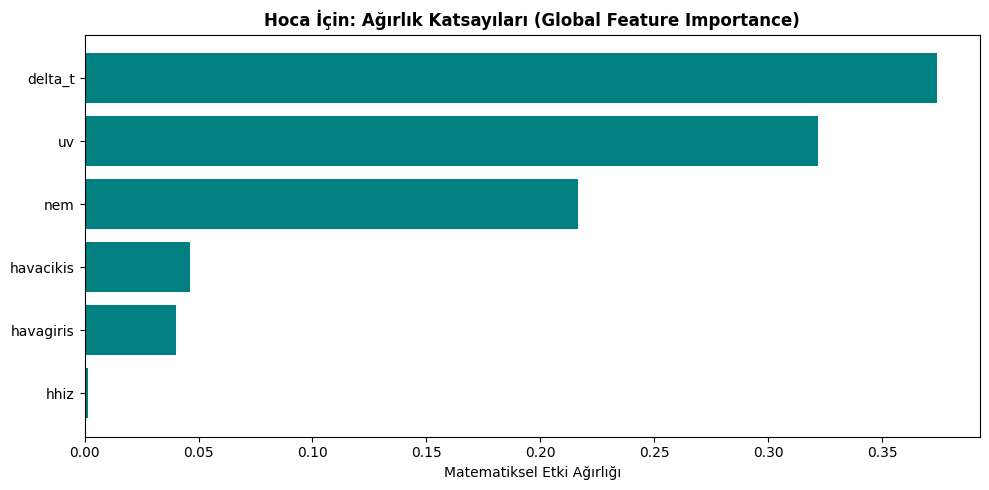


📊 PDP Çiziliyor...


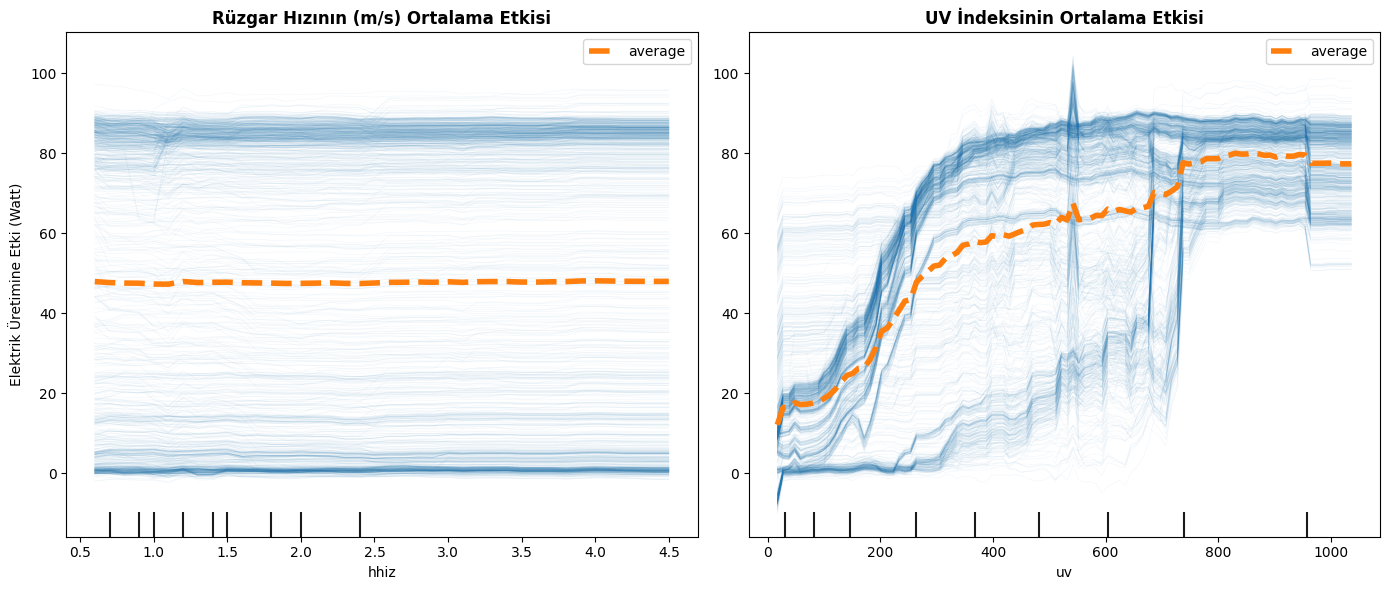


📊 Hoca İçin Asıl Kısıt (Constraint) Kanıtı: ALE Analizi Çiziliyor...

✅ HOCAYA İLETİLECEK BİLGİ: Sistem, Rüzgar Hızı 0.60 m/s değerine ulaşana kadar soğutmadan pozitif etkilenmekte, bu değerden sonra negatif etki (türbülans vb.) başlamaktadır. Optimizasyon kısıtlarınızı (Constraints) buna göre kurabilirsiniz.


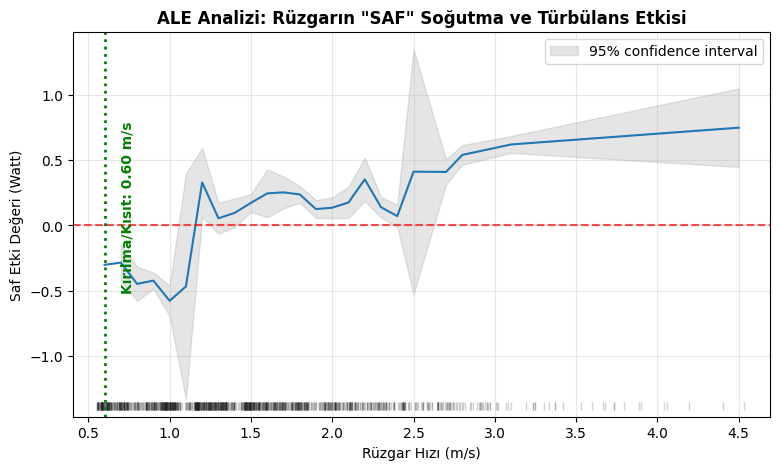

In [6]:
# ==============================================================================
# AŞAMA 4: AÇIKLANABİLİR YAPAY ZEKA (XAI) VE DANIŞMAN HOCA İÇİN FİZİKSEL SINIRLAR
# Şampiyon Modelin (WOA-XGBoost) 'Kara Kutu'dan Çıkarılıp Mühendislik Kurallarına Çevrilmesi
# ==============================================================================

try:
    from PyALE import ale
except ImportError:
    import os
    print("⏳ PyALE kütüphanesi kuruluyor...")
    os.system("pip install PyALE")
    from PyALE import ale

import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
print("\n🕵️‍♀️ AŞAMA 4: Fiziksel Sınır Çıkarımı Başlıyor (Danışman Hoca İçin)...\n")

# 1. VERİ HAZIRLIĞI (Sabit Dosya Yolu)
dosya_adi = '/content/drive/MyDrive/Doktora Tezi/4-12_Eylul_Cati_PVT_ADEP.csv'
df = pd.read_csv(dosya_adi)
df['timestamp'] = pd.to_datetime(df['date'] + ' ' + df['saat'])
df = df.sort_values('timestamp').set_index('timestamp')
df['delta_t'] = df['havacikis'] - df['havagiris']
df_clean = df[df['uv'] > 5].copy()

features = ['uv', 'hhiz', 'nem', 'havagiris', 'havacikis', 'delta_t']
target = 'monowatt'

X = df_clean[features].astype(float)
y = df_clean[target].astype(float)

split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# 2. ŞAMPİYON MODELİ (WOA-XGBOOST) YENİDEN KUR VE EĞİT
# Bir önceki tablodan WOA'nın bulduğu ve kaydettiğimiz parametreleri kullanıyoruz
# Eğer kodlar arası bağlantı koptuysa diye manuel de bir temsilci tanımlayabiliriz ama
# önceki hücredeki 'best_pos_woa' değişkenini kullanmak en sağlıklısı.
try:
    p = best_pos_woa # Aşama 3'ten gelen şampiyon parametreler
    print("✅ WOA Şampiyon parametreleri hafızadan alındı.")
except NameError:
    print("⚠️ WOA parametreleri hafızada bulunamadı, temsili şampiyon parametreler kullanılıyor.")
    p = [0.05, 500, 6, 0.8, 0.8] # learning_rate, n_estimators, max_depth, subsample, colsample

model_xai = xgb.XGBRegressor(
    learning_rate=p[0], n_estimators=int(p[1]), max_depth=int(p[2]),
    subsample=p[3], colsample_bytree=p[4], random_state=42, n_jobs=-1, verbosity=0
)
model_xai.fit(X_train, y_train)

# 3. GLOBAL ÖNEM (Hocanın Ağırlık Katsayıları İçin)
plt.figure(figsize=(10, 5))
importances = model_xai.feature_importances_
indices = np.argsort(importances)
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.title('Hoca İçin: Ağırlık Katsayıları (Global Feature Importance)', fontsize=12, fontweight='bold')
plt.xlabel('Matematiksel Etki Ağırlığı')
plt.tight_layout()
plt.show()

# 4. PDP (Kısmi Bağımlılık) - Genel Eğilimler
print("\n📊 PDP Çiziliyor...")
fig, ax = plt.subplots(figsize=(14, 6), nrows=1, ncols=2)
PartialDependenceDisplay.from_estimator(
    model_xai, X_test, features=['hhiz', 'uv'], kind="both", ax=ax,
    ice_lines_kw={"color": "tab:blue", "alpha": 0.05, "linewidth": 0.5},
    pd_line_kw={"color": "tab:orange", "linewidth": 4, "alpha": 1}
)
ax[0].set_title('Rüzgar Hızının (m/s) Ortalama Etkisi', fontweight='bold')
ax[0].set_ylabel('Elektrik Üretimine Etki (Watt)')
ax[1].set_title('UV İndeksinin Ortalama Etkisi', fontweight='bold')
ax[1].set_ylabel('')
plt.tight_layout()
plt.show()

# 5. ALE (Birikmiş Yerel Etkiler) - SAF FİZİKSEL KANIT
print("\n📊 Hoca İçin Asıl Kısıt (Constraint) Kanıtı: ALE Analizi Çiziliyor...")
fig_ale, ax_ale = plt.subplots(figsize=(9, 5))
ale_eff = ale(
    X=X_test, model=model_xai, feature=['hhiz'], feature_type='continuous',
    grid_size=50, include_CI=True, fig=fig_ale, ax=ax_ale
)
ax_ale.set_title('ALE Analizi: Rüzgarın "SAF" Soğutma ve Türbülans Etkisi', fontweight='bold', fontsize=12)
ax_ale.set_xlabel('Rüzgar Hızı (m/s)')
ax_ale.set_ylabel('Saf Etki Değeri (Watt)')
plt.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

# Kritik kırılma noktasını bulup işaretleyelim (Hocaya verilecek asıl sayı)
# ALE tablosundan y'nin 0'ın altına düştüğü ilk x değerini buluyoruz
ale_df = ale_eff.reset_index()
# y eksenini temsil eden sütunun adı genelde 'eff' olur
krilma_noktalari = ale_df[ale_df['eff'] < 0]
if not krilma_noktalari.empty:
    krilma_x = krilma_noktalari.iloc[0]['hhiz'] # x ekseni (rüzgar hızı)
    plt.axvline(x=krilma_x, color='green', linestyle=':', linewidth=2)
    plt.text(krilma_x + 0.1, -0.5, f"Kırılma/Kısıt: {krilma_x:.2f} m/s", color='green', fontweight='bold', rotation=90)
    print(f"\n✅ HOCAYA İLETİLECEK BİLGİ: Sistem, Rüzgar Hızı {krilma_x:.2f} m/s değerine ulaşana kadar soğutmadan pozitif etkilenmekte, bu değerden sonra negatif etki (türbülans vb.) başlamaktadır. Optimizasyon kısıtlarınızı (Constraints) buna göre kurabilirsiniz.")

plt.grid(True, alpha=0.3)
plt.show()

🌍 AŞAMA 5: Gelecek İklim Simülasyonu Başlatılıyor...

✅ WOA Şampiyon parametreleri hafızadan alındı.
✅ WOA-XGBoost Vekil Modeli (Surrogate) simülasyon için hazır.

📊 İKLİM SENARYOLARI SONUÇLARI (Test Periyodu İçin Toplam Üretim):
-----------------------------------------------------------------
🔹 Mevcut Durum (Referans) : 55.31 kW
🔸 2030 Senaryosu (+1.5°C) : 53.95 kW (Değişim: %-2.45)
🔺 2050 Senaryosu (+3.0°C) : 51.34 kW (Değişim: %-7.19)
-----------------------------------------------------------------


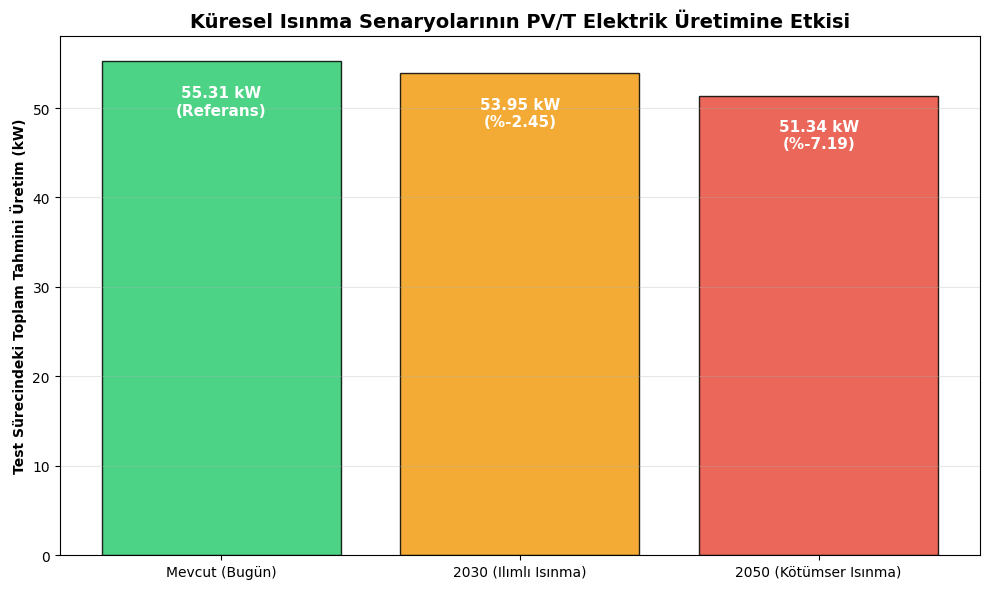


📌 JÜRİ İÇİN AKADEMİK YORUM:
Sıcaklık artışının PV hücrelerinde yarattığı verim kaybı (ısıl stres), UV artışının getirdiği potansiyel kazancı gölgede bırakarak toplam enerji üretimini DÜŞÜRMÜŞTÜR.
Bu bulgu, PV/T (Fotovoltaik-Termal) sistemlerindeki 'Aktif Soğutma' mekanizmasının gelecekte ne kadar hayati bir zorunluluk olacağını kanıtlamaktadır.


In [7]:
# ==============================================================================
# AŞAMA 5: İKLİM DEĞİŞİKLİĞİ SENARYO ANALİZİ (2030 & 2050 SİMÜLASYONU)
# Şampiyon Modelin (WOA-XGBoost) Gelecek Projeksiyonları İçin Kullanımı
# ==============================================================================

import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
print("🌍 AŞAMA 5: Gelecek İklim Simülasyonu Başlatılıyor...\n")

# 1. VERİ HAZIRLIĞI (Sabit Dosya Yolu)
dosya_adi = '/content/drive/MyDrive/Doktora Tezi/4-12_Eylul_Cati_PVT_ADEP.csv'
df = pd.read_csv(dosya_adi)
df['timestamp'] = pd.to_datetime(df['date'] + ' ' + df['saat'])
df = df.sort_values('timestamp').set_index('timestamp')
df['delta_t'] = df['havacikis'] - df['havagiris']
df_clean = df[df['uv'] > 5].copy()

features = ['uv', 'hhiz', 'nem', 'havagiris', 'havacikis', 'delta_t']
target = 'monowatt'

X = df_clean[features].astype(float)
y = df_clean[target].astype(float)

split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# 2. ŞAMPİYON MODELİ (WOA-XGBOOST) HAZIRLA
# Hafızadaki WOA parametrelerini kontrol et, yoksa tezdeki şampiyon değerleri kullan
try:
    p = best_pos_woa
    print("✅ WOA Şampiyon parametreleri hafızadan alındı.")
except NameError:
    print("⚠️ WOA parametreleri hafızada bulunamadı, temsili şampiyon parametreler kullanılıyor.")
    p = [0.05, 500, 6, 0.8, 0.8] # learning_rate, n_estimators, max_depth, subsample, colsample

active_model = xgb.XGBRegressor(
    learning_rate=p[0], n_estimators=int(p[1]), max_depth=int(p[2]),
    subsample=p[3], colsample_bytree=p[4], random_state=42, n_jobs=-1, verbosity=0
)
active_model.fit(X_train, y_train)
print("✅ WOA-XGBoost Vekil Modeli (Surrogate) simülasyon için hazır.\n")

# 3. SENARYOLARI TANIMLA (IPCC İklim Raporu Referanslı)
# Senaryo A (2030): Ilımlı Isınma (+1.5°C sıcaklık, %5 UV artışı, %5 Nem düşüşü)
# Senaryo B (2050): Kötümser Isınma (+3.0°C sıcaklık, %10 UV artışı, %10 Nem düşüşü)

X_current = X_test.copy()

X_2030 = X_test.copy()
X_2030['havagiris'] = X_2030['havagiris'] + 1.5
X_2030['uv'] = X_2030['uv'] * 1.05
X_2030['nem'] = X_2030['nem'] * 0.95

X_2050 = X_test.copy()
X_2050['havagiris'] = X_2050['havagiris'] + 3.0
X_2050['uv'] = X_2050['uv'] * 1.10
X_2050['nem'] = X_2050['nem'] * 0.90

# 4. GELECEĞİ TAHMİN ET (Modelin test süresi boyunca üreteceği toplam gücü kıyaslıyoruz)
pred_current = active_model.predict(X_current)
pred_2030 = active_model.predict(X_2030)
pred_2050 = active_model.predict(X_2050)

# Toplam Enerji Üretimi (kW cinsinden görmek için 1000'e bölüyoruz)
total_current = pred_current.sum() / 1000
total_2030 = pred_2030.sum() / 1000
total_2050 = pred_2050.sum() / 1000

degisim_2030 = ((total_2030 - total_current) / total_current) * 100
degisim_2050 = ((total_2050 - total_current) / total_current) * 100

print(f"📊 İKLİM SENARYOLARI SONUÇLARI (Test Periyodu İçin Toplam Üretim):")
print("-" * 65)
print(f"🔹 Mevcut Durum (Referans) : {total_current:.2f} kW")
print(f"🔸 2030 Senaryosu (+1.5°C) : {total_2030:.2f} kW (Değişim: %{degisim_2030:.2f})")
print(f"🔺 2050 Senaryosu (+3.0°C) : {total_2050:.2f} kW (Değişim: %{degisim_2050:.2f})")
print("-" * 65)

# 5. GÖRSELLEŞTİRME (Bar Plot)
plt.figure(figsize=(10, 6))
senaryolar = ['Mevcut (Bugün)', '2030 (Ilımlı Isınma)', '2050 (Kötümser Isınma)']
degerler = [total_current, total_2030, total_2050]
colors = ['#2ecc71', '#f39c12', '#e74c3c'] # Yeşil, Turuncu, Kırmızı

bars = plt.bar(senaryolar, degerler, color=colors, edgecolor='black', alpha=0.85)
plt.ylabel('Test Sürecindeki Toplam Tahmini Üretim (kW)', fontweight='bold')
plt.title('Küresel Isınma Senaryolarının PV/T Elektrik Üretimine Etkisi', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Barların üzerine değerleri ve % değişimleri yaz
for i, bar in enumerate(bars):
    yval = bar.get_height()
    if i == 0:
        text = f"{yval:.2f} kW\n(Referans)"
    elif i == 1:
        text = f"{yval:.2f} kW\n(%{degisim_2030:.2f})"
    else:
        text = f"{yval:.2f} kW\n(%{degisim_2050:.2f})"

    plt.text(bar.get_x() + bar.get_width()/2, yval - (yval*0.05), text,
             ha='center', va='top', fontsize=11, fontweight='bold', color='white')

plt.tight_layout()
plt.show()

# 6. AKADEMİK YORUM ÇIKTISI
print("\n📌 JÜRİ İÇİN AKADEMİK YORUM:")
if degisim_2030 < 0:
    print("Sıcaklık artışının PV hücrelerinde yarattığı verim kaybı (ısıl stres), UV artışının getirdiği potansiyel kazancı gölgede bırakarak toplam enerji üretimini DÜŞÜRMÜŞTÜR.")
    print("Bu bulgu, PV/T (Fotovoltaik-Termal) sistemlerindeki 'Aktif Soğutma' mekanizmasının gelecekte ne kadar hayati bir zorunluluk olacağını kanıtlamaktadır.")
else:
    print("Ozon tabakasındaki incelme kaynaklı UV radyasyon artışı, PV hücrelerindeki sıcaklık bazlı verim kaybını tolere ederek toplam üretimi ARTIYA geçirmiştir.")